# Phase-4 Stage-A — inspect one training example

The training data for the running Kuma jobs lives in **`/work/upthomae/Meng/phase4/stageA_full_npz/`**.
Each **complex** is three `.npz` files:

| file | holds |
|---|---|
| `<id>__holo__p1.npz` | the **heterogeneous graph** of protein chain 1 (partner A) |
| `<id>__holo__p2.npz` | the heterogeneous graph of chain 2 (partner B) |
| `<id>__contacts.npz` | the **true interface contacts** (surface-atom row pairs) — the training labels |

**The core design idea to keep in mind:** the GNN encoder consumes *only* invariant quantities —
node features, edge **distances**, edge **cos-angles**, and connectivity. It **never sees raw 3D
coordinates**, so the learned embedding is exactly SE(3)-invariant by construction. The `coord`
array *is* stored (for negative sampling), which conveniently lets us reconstruct the 3D interface
for visualization here — but the network does not use it.

> Run with the **`masif-graph`** kernel (py3.11: numpy / matplotlib / pandas). Self-contained: only
> needs the npz folder.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

NPZ = "/work/upthomae/Meng/phase4/stageA_full_npz"
CID = "1A0G_A_B"          # <-- change to any id in stageA_full_train_ids.txt

def load(cid):
    p1 = dict(np.load(f"{NPZ}/{cid}__holo__p1.npz", allow_pickle=False))
    p2 = dict(np.load(f"{NPZ}/{cid}__holo__p2.npz", allow_pickle=False))
    ct = dict(np.load(f"{NPZ}/{cid}__contacts.npz", allow_pickle=False))
    return p1, p2, ct

p1, p2, ct = load(CID)
n_all = len({f.rsplit('__', 1)[0].replace('__holo','') for f in os.listdir(NPZ)})
print(f"folder has ~{n_all} complexes; loaded {CID}")
print("chain1 keys:", list(p1))

folder has ~4872 complexes; loaded 1A0G_A_B
chain1 keys: ['atom_feat', 'aa_edge', 'aa_order', 'aa_rot', 'vert_feat', 'vv_edge', 'vv_dist', 'vv_cos', 'va_v', 'va_a', 'va_dist', 'va_cos', 'surf_node_idx', 'n_surf', 'desc_straight', 'desc_flipped', 'coord', 'keys']


## 1. What every array means

The heterogeneous graph has **two node types** (surface **vertices** from the MaSIF mesh, and heavy
**atoms**) and **three edge types**. Below is the full schema for one chain.

In [2]:
MEANING = {
 "atom_feat":  "atom NODE features (14-D, invariant): Phase-2 base(10: element/backbone/aromatic/degree…) + flex-depth(1) + element-chem(3: electronegativity/valence/covalent-radius). Normalized.",
 "aa_edge":    "atom–atom COVALENT edges, index [2, n_edge] into atom nodes (no through-space edges — those would inject pose sensitivity).",
 "aa_order":   "covalent edge feature: bond-order one-hot [single, double, aromatic, other] (biotite residue-template connectivity).",
 "aa_rot":     "covalent edge feature: is this a rotatable side-chain bond? {0,1} — the whole point of the graph (encode how side chains can move).",
 "vert_feat":  "surface-vertex NODE features (4-D, ~[-1,1]): [shape-index, hbond, charge, hydrophobicity] — MaSIF's hand-crafted input channels (NOT its learned descriptor).",
 "vv_edge":    "vertex–vertex MESH edges (from .ply faces), index [2, n_edge] into vertex nodes.",
 "vv_dist":    "mesh edge feature: edge length (Å).",
 "vv_cos":     "mesh edge feature: cos angle between the two vertex normals (local curvature).",
 "va_v":       "vertex–atom edges: vertex endpoint (radius-ball ≤5Å, ≤8 nearest).",
 "va_a":       "vertex–atom edges: atom endpoint (which heavy atom sits under this surface patch).",
 "va_dist":    "vertex–atom edge feature: distance (Å, ≤5).",
 "va_cos":     "vertex–atom edge feature: cos(vertex-normal, atom→vertex direction).",
 "surf_node_idx":"for each SURFACE-atom row, which atom node it is (z[r] = atom_state[idx[r]]).",
 "n_surf":     "number of surface atoms (the rows the descriptor / contacts are defined over).",
 "desc_straight":"frozen MaSIF 80-D descriptor, mean-pooled to surface atoms — REFERENCE ONLY (the 0.947 'ceiling'); the GNN does not use it.",
 "desc_flipped":"frozen MaSIF descriptor, flipped-fingerprint variant (for complementary matching).",
 "coord":      "surface-atom xyz (Å) — for negative sampling + OUR viz. The network never reads this.",
 "keys":       "surface-atom identity 'chain:resSeq:atomName' (bytes).",
}
rows=[]
for k in p1:
    a=p1[k]; rng=""
    if a.dtype.kind in "fi" and a.size: rng=f"[{a.min():.3g}, {a.max():.3g}]"
    rows.append((k, str(a.shape), str(a.dtype), rng, MEANING.get(k,"")))
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows, columns=["array","shape","dtype","range","meaning"])

,array,shape,dtype,range,meaning
0,atom_feat,"(2253, 14)",float32,"[0, 1]","atom NODE features (14-D, invariant): Phase-2 base(10: element/backbone/aromatic/degre..."
1,aa_edge,"(2, 4598)",int64,"[0, 2.25e+03]","atom–atom COVALENT edges, index [2, n_edge] into atom nodes (no through-space edges — ..."
2,aa_order,"(4598, 4)",float32,"[0, 1]","covalent edge feature: bond-order one-hot [single, double, aromatic, other] (biotite r..."
3,aa_rot,"(4598,)",float32,"[0, 1]","covalent edge feature: is this a rotatable side-chain bond? {0,1} — the whole point of..."
4,vert_feat,"(5689, 4)",float32,"[-1, 1]","surface-vertex NODE features (4-D, ~[-1,1]): [shape-index, hbond, charge, hydrophobici..."
5,vv_edge,"(2, 17067)",int64,"[0, 5.69e+03]","vertex–vertex MESH edges (from .ply faces), index [2, n_edge] into vertex nodes."
6,vv_dist,"(17067,)",float32,"[1, 3.53]",mesh edge feature: edge length (Å).
7,vv_cos,"(17067,)",float32,"[-0.455, 1]",mesh edge feature: cos angle between the two vertex normals (local curvature).
8,va_v,"(43843,)",int64,"[0, 5.69e+03]","vertex–atom edges: vertex endpoint (radius-ball ≤5Å, ≤8 nearest)."
9,va_a,"(43843,)",int64,"[0, 2.25e+03]",vertex–atom edges: atom endpoint (which heavy atom sits under this surface patch).


## 2. Scale of this example

Note the asymmetry: **many** vertices (fine surface mesh) → **fewer** atoms → **fewer still** surface
atoms (the pooled unit that carries a descriptor and can be a contact).

In [3]:
def scale(tag, g):
    return {"chain":tag, "atoms":g["atom_feat"].shape[0], "vertices":g["vert_feat"].shape[0],
            "surface_atoms":int(g["n_surf"]),
            "covalent_edges":g["aa_edge"].shape[1], "mesh_edges":g["vv_edge"].shape[1],
            "vertex_atom_edges":g["va_v"].shape[0]}
disp = pd.DataFrame([scale("p1",p1), scale("p2",p2)]).set_index("chain")
print(disp.to_string())
print(f"\ncontacts (labels): dense = {ct['pos'].shape[0]} pairs   sc-filtered = {ct['pos_sc'].shape[0]} pairs")
print("each contact row = (p1 surface-atom index, p2 surface-atom index)")
print("example dense pairs:\n", ct["pos"][:5])

       atoms  vertices  surface_atoms  covalent_edges  mesh_edges  vertex_atom_edges
chain                                                                               
p1      2253      5689           1261            4598       17067              43843
p2      2272      5844           1265            4638       17532              45029

contacts (labels): dense = 267 pairs   sc-filtered = 76 pairs
each contact row = (p1 surface-atom index, p2 surface-atom index)
example dense pairs:
 [[ 11 105]
 [ 12 105]
 [ 78  80]
 [ 79  81]
 [ 80  80]]


## 3. Node & edge feature distributions

The invariant quantities the GNN actually learns from. Left→right: the 4 vertex channels, the two
mesh-edge geometry features, the two vertex–atom geometry features, and the covalent bond-type mix.

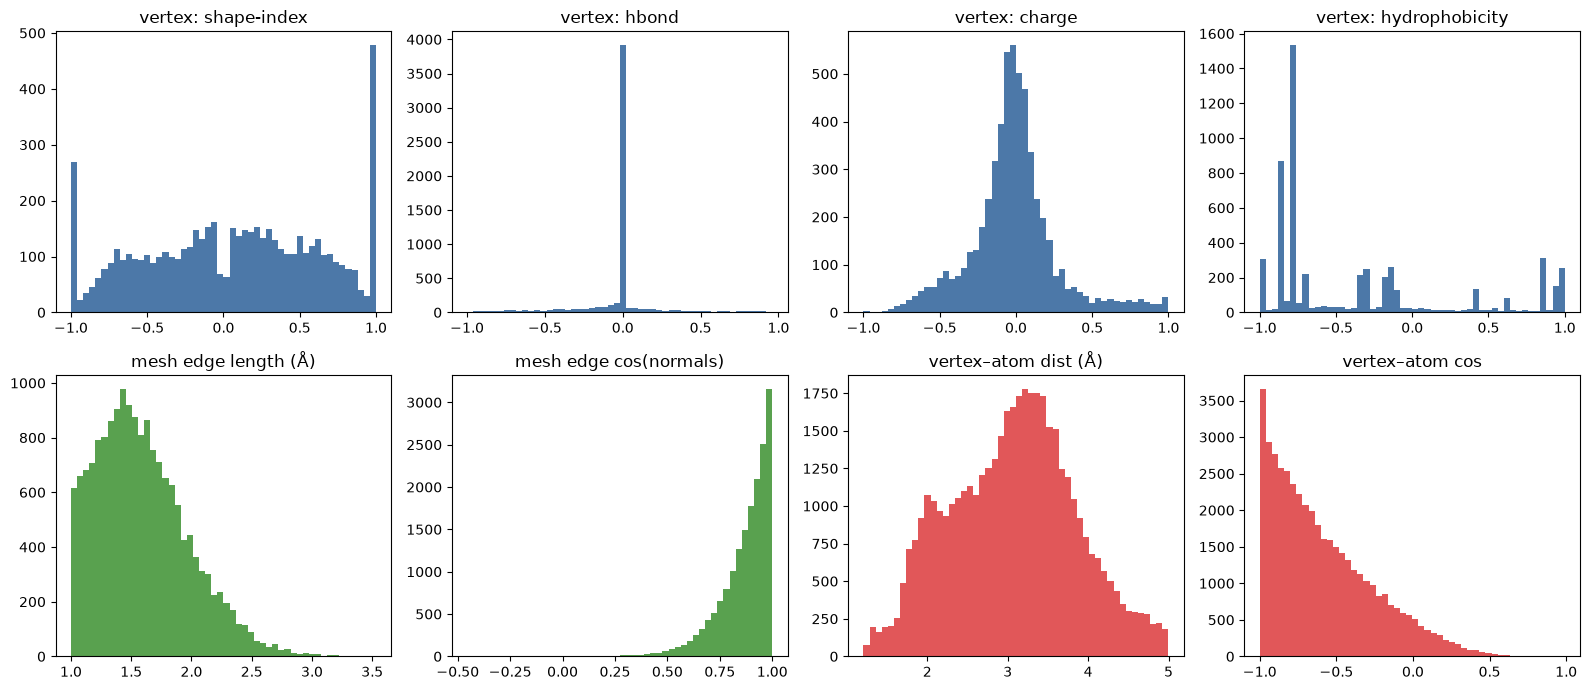

covalent bond-order mix: {'single': 3494, 'double': 714, 'aromatic': 390, 'other': 0}
rotatable side-chain bonds: 24% of covalent edges


In [4]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7)); ax=ax.ravel()
vf = p1["vert_feat"]
for i,name in enumerate(["shape-index","hbond","charge","hydrophobicity"]):
    ax[i].hist(vf[:,i], bins=50, color="#4C78A8"); ax[i].set_title(f"vertex: {name}")
ax[4].hist(p1["vv_dist"], bins=50, color="#59A14F"); ax[4].set_title("mesh edge length (Å)")
ax[5].hist(p1["vv_cos"],  bins=50, color="#59A14F"); ax[5].set_title("mesh edge cos(normals)")
ax[6].hist(p1["va_dist"], bins=50, color="#E15759"); ax[6].set_title("vertex–atom dist (Å)")
ax[7].hist(p1["va_cos"],  bins=50, color="#E15759"); ax[7].set_title("vertex–atom cos")
plt.tight_layout(); plt.show()

order_names=["single","double","aromatic","other"]  # build.py order_map: 1→single,2→double,{5,6,7,8}→aromatic,else→other
mix = p1["aa_order"].sum(0)
print("covalent bond-order mix:", {order_names[i]:int(mix[i]) for i in range(4)})
print(f"rotatable side-chain bonds: {p1['aa_rot'].mean()*100:.0f}% of covalent edges")

## 4. The binding interface in 3D  ⭐

Both chains are stored in the **same coordinate frame** (the bound complex), so plotting each chain's
surface atoms and drawing a line for every true contact shows the actual interface. Chain 1 = blue,
chain 2 = red; **sc-filtered contacts** (the clean, shape-complementary set the 0.947 ceiling is measured
on) drawn bold, dense contacts faint.

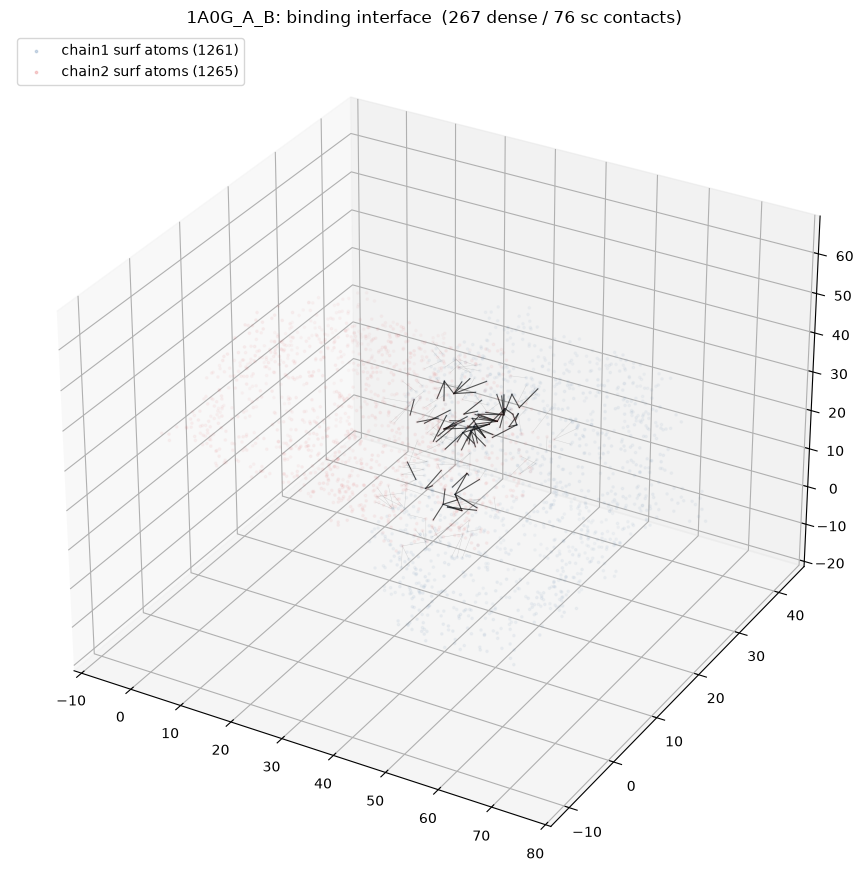

In [5]:
c1, c2 = p1["coord"], p2["coord"]
pos, possc = ct["pos"], ct["pos_sc"]

fig = plt.figure(figsize=(11,9)); axp = fig.add_subplot(111, projection="3d")
axp.scatter(*c1.T, s=3, c="#4C78A8", alpha=.25, label=f"chain1 surf atoms ({len(c1)})")
axp.scatter(*c2.T, s=3, c="#E15759", alpha=.25, label=f"chain2 surf atoms ({len(c2)})")
# dense contacts (faint), subsample if many
for a,b in pos[np.random.default_rng(0).choice(len(pos), min(len(pos),150), replace=False)]:
    axp.plot(*np.c_[c1[a], c2[b]], c="gray", lw=.3, alpha=.3)
# sc contacts (bold)
for a,b in possc:
    axp.plot(*np.c_[c1[a], c2[b]], c="#111", lw=.8, alpha=.7)
axp.set_title(f"{CID}: binding interface  ({len(pos)} dense / {len(possc)} sc contacts)")
axp.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 5. Zoom: only the interface atoms

Grey the non-contacting surface; highlight the surface atoms that actually participate in a contact.
This is the region correspondence learning has to get right.

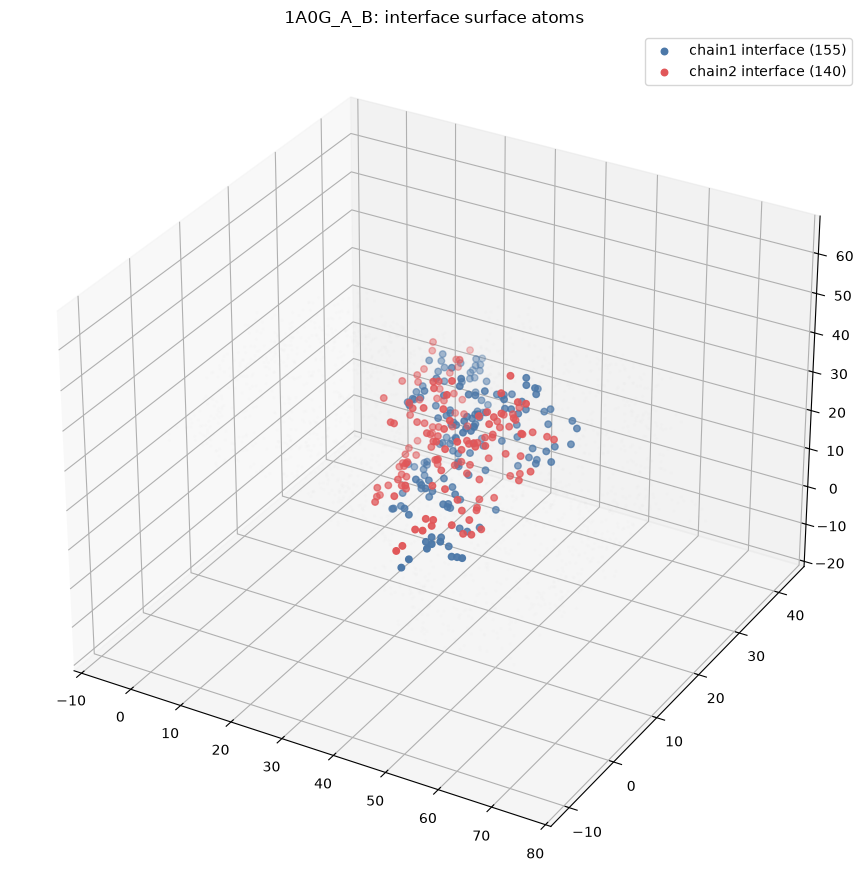

In [6]:
i1 = np.unique(pos[:,0]); i2 = np.unique(pos[:,1])
m1 = np.zeros(len(c1),bool); m1[i1]=True
m2 = np.zeros(len(c2),bool); m2[i2]=True
fig = plt.figure(figsize=(11,9)); axz = fig.add_subplot(111, projection="3d")
axz.scatter(*c1[~m1].T, s=2, c="#CCC", alpha=.15)
axz.scatter(*c2[~m2].T, s=2, c="#CCC", alpha=.15)
axz.scatter(*c1[m1].T, s=22, c="#4C78A8", label=f"chain1 interface ({m1.sum()})")
axz.scatter(*c2[m2].T, s=22, c="#E15759", label=f"chain2 interface ({m2.sum()})")
axz.set_title(f"{CID}: interface surface atoms"); axz.legend(); plt.tight_layout(); plt.show()

## 6. The frozen MaSIF descriptor — the 0.947 "ceiling", visualized

This connects the data to the project's central metric. For each **true contact** `(i, j)` the frozen
score is `1 / ‖desc_straight¹[i] − desc_flipped²[j]‖`; contacting pairs should score **higher** than
random cross pairs. The separation you see *is* the ~0.90 holo ceiling the from-scratch GNN is trying to
re-earn. (Single complex here — the reported 0.947 is pooled over all 60 held-out complexes.)

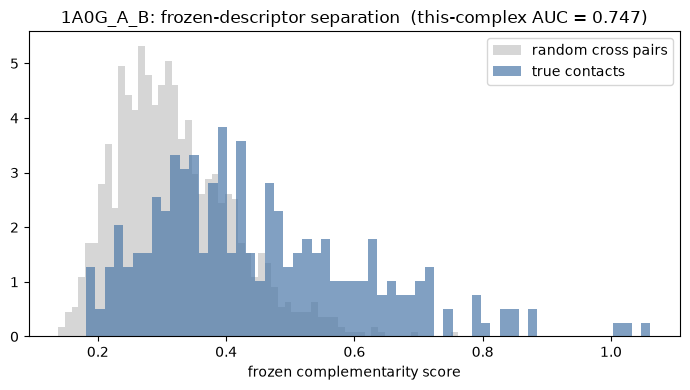

In [7]:
def frozen_score(i, j):
    d = p1["desc_straight"][i] - p2["desc_flipped"][j]
    return 1.0/(np.sqrt((d*d).sum(1))+1e-9)

rng = np.random.default_rng(0)
pos_s = frozen_score(pos[:,0], pos[:,1])
ri = rng.integers(0, len(c1), 4*len(pos)); rj = rng.integers(0, len(c2), 4*len(pos))
neg_s = frozen_score(ri, rj)

# rank-based AUC (no sklearn dependency)
def auc(pos_s, neg_s):
    s = np.r_[pos_s, neg_s]; y = np.r_[np.ones(len(pos_s)), np.zeros(len(neg_s))]
    order = np.argsort(s); r = np.empty(len(s)); r[order] = np.arange(1, len(s)+1)
    n1 = y.sum(); n0 = len(y)-n1
    return (r[y==1].sum() - n1*(n1+1)/2) / (n1*n0)

plt.figure(figsize=(7,4))
plt.hist(neg_s, bins=60, alpha=.6, label="random cross pairs", color="#BBB", density=True)
plt.hist(pos_s, bins=60, alpha=.7, label="true contacts", color="#4C78A8", density=True)
plt.legend(); plt.xlabel("frozen complementarity score"); plt.title(
    f"{CID}: frozen-descriptor separation  (this-complex AUC = {auc(pos_s,neg_s):.3f})")
plt.tight_layout(); plt.show()

## 7. Color the surface by descriptor structure

Surface atoms of chain 1 colored by the 1st principal component of the frozen 80-D descriptor — shows
that the descriptor varies smoothly and coherently across the surface (chemically/geometrically similar
patches get similar colors), the structure the GNN is trying to reconstruct from scratch.

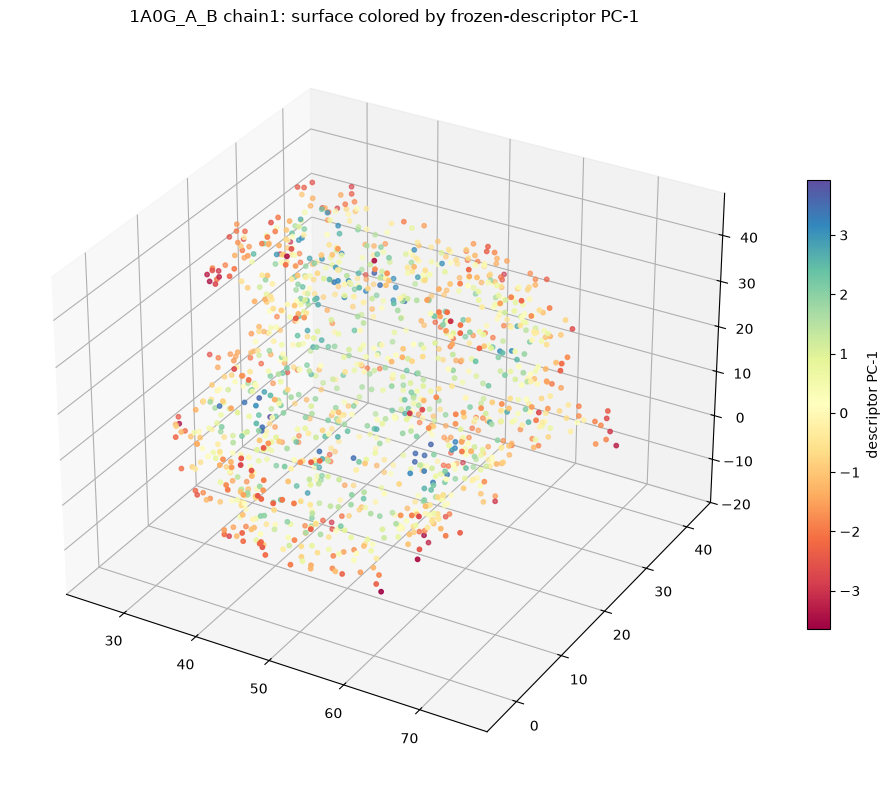

In [8]:
D = p1["desc_straight"]; Dc = D - D.mean(0)
pc1 = Dc @ np.linalg.svd(Dc, full_matrices=False)[2][0]
fig = plt.figure(figsize=(10,8)); axc = fig.add_subplot(111, projection="3d")
sc = axc.scatter(*c1.T, s=10, c=pc1, cmap="Spectral")
plt.colorbar(sc, shrink=.6, label="descriptor PC-1")
axc.set_title(f"{CID} chain1: surface colored by frozen-descriptor PC-1"); plt.tight_layout(); plt.show()

## 8. How the message passing works  ⭐

Source: `src/masif_graph/p4/encoder.py`. The encoder turns one chain's heterogeneous graph into a
**32-D embedding per surface atom** (`z`). It has **two node types** — surface **vertices** (4-D features)
and heavy **atoms** (14-D features) — each first linearly embedded to a `d=64` hidden state. Then **4
identical message-passing layers** run; each layer moves information along **four directed relations**:

| relation | direction | edge features | what it carries |
|---|---|---|---|
| **aa** | atom → atom | bond-order + rotatable flag | covalent/sidechain connectivity |
| **vv** | vertex → vertex | mesh-edge length, cos(normals) | the *learnable geodesic conv* (replaces MaSIF's CNN) |
| **va** | vertex → atom | dist, cos(normal, atom−vertex) | surface signal lands on atoms |
| **av** | atom → vertex | (same va edges, reversed) | atom chemistry lifts back to the surface |

For every edge, the **message** is `MLP([h_source, edge_feature])`, and messages are **mean-aggregated**
per destination. Each node then updates with a residual + LayerNorm:

```
h_atom   ← LayerNorm( h_atom   + MLP[ h_atom ,  mean(aa msgs),  mean(va msgs) ] )
h_vertex ← LayerNorm( h_vertex + MLP[ h_vertex,  mean(vv msgs),  mean(av msgs) ] )
```

After 4 layers, a **readout MLP** is applied at the surface-atom nodes only → `z` (n_surf, 32).
**Crucially, no coordinate ever enters** — only node features and edge *scalars* (distances, cos-angles),
which are the same under any rotation/translation, so `z` is SE(3)-invariant by construction.

In [ ]:
# --- schematic of one message-passing layer ---
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 6.2)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 7)
def box(x, y, w, h, txt, c):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", fc=c, ec="k", lw=1.5))
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=11)
box(0.8, 4.4, 3.2, 1.5, "VERTEX nodes\n(surface mesh · 4-D feat)", "#BBD7EC")
box(6.0, 4.4, 3.2, 1.5, "ATOM nodes\n(heavy atoms · 14-D feat)", "#F4C7C3")

def arr(x1, y1, x2, y2, txt, dy=0.18, color="k", rad=0.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16,
                 color=color, lw=1.7, connectionstyle=f"arc3,rad={rad}"))
    ax.text((x1+x2)/2, (y1+y2)/2 + dy, txt, ha="center", fontsize=9, color=color)
arr(1.4, 6.05, 3.4, 6.05, "vv: mesh (geodesic conv)", 0.12, "#2E7D32", rad=-0.6)
arr(6.6, 6.05, 8.6, 6.05, "aa: covalent bonds",       0.12, "#B71C1C", rad=-0.6)
arr(4.0, 5.35, 6.0, 5.35, "va: vertex→atom", 0.16, "#444", rad=0.25)
arr(6.0, 4.65, 4.0, 4.65, "av: atom→vertex", -0.34, "#444", rad=0.25)

ax.text(5, 2.75,
        "message = MLP([ h_source , edge_feature ])   →   mean-aggregate per destination\n\n"
        "h_atom    ← LayerNorm( h_atom    + MLP[ h_atom ,  Σ aa ,  Σ va ] )\n"
        "h_vertex  ← LayerNorm( h_vertex  + MLP[ h_vertex,  Σ vv ,  Σ av ] )",
        ha="center", va="center", fontsize=9.5, family="monospace")
ax.text(5, 0.7, "× 4 layers, then a readout MLP at the SURFACE ATOMS  →  32-D embedding z",
        ha="center", fontsize=10.5, weight="bold")
ax.set_title("Phase-4 heterogeneous message passing  (one layer)", fontsize=12)
plt.tight_layout(); plt.show()

## 9. Receptive field — what ONE surface atom "sees" after each layer

Each message-passing layer lets a node pull information from its immediate graph neighbours. So after
`L` layers, a surface atom's embedding integrates everything within **`L` hops** across *all* edge types
(covalent bonds, mesh, vertex↔atom). Below we take a real contacting surface atom, do a breadth-first
search over the combined heterogeneous graph, and count how many atoms and vertices fall into its
receptive field after 1, 2, 3, 4 layers — i.e. how big a surface patch + sidechain neighbourhood the
learned descriptor actually summarises.

In [ ]:
# --- receptive field of a target surface atom via BFS over all edge types ---
from collections import defaultdict

na, nv = p1["atom_feat"].shape[0], p1["vert_feat"].shape[0]   # atoms 0..na-1 ; vertices na..na+nv-1
adj = defaultdict(set)
def link(u, v): adj[u].add(v); adj[v].add(u)
ae = p1["aa_edge"]
for k in range(ae.shape[1]): link(int(ae[0, k]), int(ae[1, k]))            # atom-atom covalent
ve = p1["vv_edge"]
for k in range(ve.shape[1]): link(na + int(ve[0, k]), na + int(ve[1, k]))  # vertex-vertex mesh
vv_, va_ = p1["va_v"], p1["va_a"]
for k in range(len(vv_)): link(int(va_[k]), na + int(vv_[k]))              # vertex-atom

sni = p1["surf_node_idx"]                       # surf-row -> atom-node index
tgt_node = int(sni[int(ct["pos"][0, 0])])       # a real contacting p1 surface atom

seen = {tgt_node: 0}; frontier = [tgt_node]; rows = []
for hop in range(0, 5):
    a = sum(1 for n, d in seen.items() if d <= hop and n <  na)
    v = sum(1 for n, d in seen.items() if d <= hop and n >= na)
    rows.append((hop, a, v))
    nxt = []
    for n in frontier:
        for m in adj[n]:
            if m not in seen: seen[m] = hop + 1; nxt.append(m)
    frontier = nxt

import pandas as pd
df = pd.DataFrame(rows, columns=["layer (hops)", "atoms in field", "vertices in field"]).set_index("layer (hops)")
print(f"target = surface atom node {tgt_node}  (graph has {na} atoms, {nv} vertices)\n")
print(df.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df.index, df["atoms in field"],    "o-", c="#B71C1C", label="atoms reached")
ax.plot(df.index, df["vertices in field"], "s-", c="#2E7D32", label="vertices reached")
ax.set_xlabel("message-passing layer (= BFS hops)"); ax.set_ylabel("nodes in receptive field")
ax.set_title("Receptive field of one surface atom grows with depth"); ax.legend(); ax.set_xticks(range(5))
plt.tight_layout(); plt.show()
print("\n=> the 4-layer encoder summarises a surface PATCH (hundreds-thousands of mesh vertices)\n"
      "   plus the atom's covalent/sidechain neighbourhood into its 32-D descriptor.")

## 10. Run the encoder live — the embedding, its spread, and why rotation can't change it

Instantiate a **random-init** `HeteroEncoder` and run the forward pass. Two things to notice:
`z.std` (the *spread* of embeddings across surface atoms) starts healthy (~0.05-0.1) at random init —
**training is what collapses it to ~0.003** (the representation-collapse bug named in `docs/10`); and the
encoder's input dict contains **no coordinates**, so rotating the protein cannot change `z`.

In [ ]:
# --- live encoder forward (random init) ---
import sys, torch
sys.path.insert(0, "/scratch/ymeng/masif-graph/src")
from masif_graph.p4.dataset import load_chain_graph, D_AA, D_VV, D_VA
from masif_graph.p4.encoder import HeteroEncoder

g = load_chain_graph(f"{NPZ}/{CID}__holo__p1.npz", "cpu")
enc = HeteroEncoder(g["atom_feat"].shape[1], g["vert_feat"].shape[1], D_AA, D_VV, D_VA,
                    d=64, d_out=32, n_layers=4).eval()
with torch.no_grad():
    z = enc(g)
print(f"embedding z: {tuple(z.shape)}  = one 32-D descriptor per surface atom")
print(f"z_std across surface atoms = {float(z.std(0).mean()):.4f}   "
      f"(random-init ~0.05-0.1 = healthy spread;  TRAINING collapses this to ~0.003 = the bug)")

enc_inputs = ["atom_feat","vert_feat","aa_edge","aa_feat","vv_edge","vv_feat","va_v","va_a","va_feat","surf_node_idx"]
print(f"\nencoder reads only: {enc_inputs}")
print(f"'coord' among encoder inputs? {'coord' in enc_inputs}  ->  rotating the protein cannot change z "
      f"(SE(3)-invariant by construction; M0 gate max|Δz|=0).")

---
### Try another complex
Set `CID` in cell 2 to any id from `stageA_full_train_ids.txt` (or a held-out id from
`stageA_heldout_ids.txt`) and re-run. Good contrasting picks: a large multi-domain interface vs. a small
one — compare the dense-vs-sc contact counts and how tight the frozen separation is.